# 15. Next Draw Recommendation

This notebook is designed to be the operational entrypoint after a new draw is added.

If you want the project to behave like a practical recommendation workflow, this is the only notebook you should usually need to rerun.

It performs:

- lotto sync
- preprocessing refresh
- feature refresh
- optional weather refresh
- next-draw ranking and ticket recommendation

It intentionally reports two candidates:

- **strict pre-draw candidate**: uses only features that are fully knowable before the draw
- **context-imputed candidate**: uses the final representative model, but replaces unknown future weather with neutral historical values

This keeps the recommendation honest while still letting us inspect what the final selected model would prefer.

In [1]:
from pathlib import Path
import sys

CURRENT = Path.cwd().resolve()
APP_ROOT = None
for candidate in [CURRENT, *CURRENT.parents]:
    if (candidate / "src").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break

if APP_ROOT is None:
    raise RuntimeError("Could not locate app root from notebook cwd.")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment

describe_notebook_environment(APP_ROOT)

{'app_root': '/workspace', 'cwd': '/workspace/notebooks'}

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import FIGURES_DIR
from src.pipelines import (
    run_data_pipeline,
    run_feature_pipeline,
    run_sync_pipeline,
    run_weather_build_pipeline,
    run_weather_fetch_pipeline,
)
from src.recommendation import (
    DEFAULT_CONTEXT_CANDIDATE,
    DEFAULT_STRICT_CANDIDATE,
    export_next_draw_outputs,
    recommend_next_draw,
)

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

In [3]:
REFRESH_LOTTO = True
REFRESH_FEATURES = True
REFRESH_WEATHER = True
WEATHER_FETCH_FORCE = False
CONTINUE_IF_WEATHER_REFRESH_FAILS = True

STRICT_CANDIDATE = DEFAULT_STRICT_CANDIDATE.copy()
CONTEXT_CANDIDATE = DEFAULT_CONTEXT_CANDIDATE.copy()

NEXT_DRAW_DATE = None  # e.g. pd.Timestamp("2026-05-16")
RANDOM_SEED = 42
N_WEIGHTED_TICKETS = 5
N_DIVERSIFIED_TICKETS = 5

STRICT_CANDIDATE, CONTEXT_CANDIDATE

({'feature_set': 'base_plus_pattern',
  'model': 'soft_voting_ensemble',
  'training_regime': 'last_500'},
 {'feature_set': 'full_feature_set',
  'model': 'soft_voting_ensemble',
  'training_regime': 'last_500'})

In [4]:
refresh_log = []

if REFRESH_LOTTO:
    sync_result = run_sync_pipeline()
    refresh_log.append({"step": "lotto_sync", "status": "ok", "detail": str(sync_result)})
    processed_path = run_data_pipeline(source="excel")
    refresh_log.append({"step": "data_pipeline", "status": "ok", "detail": str(processed_path)})

if REFRESH_FEATURES:
    feature_df = run_feature_pipeline(window=20, save=True)
    refresh_log.append({"step": "feature_pipeline", "status": "ok", "detail": f"rows={len(feature_df)} cols={feature_df.shape[1]}"})

weather_refresh_status = "skipped"
if REFRESH_WEATHER:
    try:
        weather_fetch_bundle = run_weather_fetch_pipeline(force=WEATHER_FETCH_FORCE)
        weather_build_bundle = run_weather_build_pipeline()
        refresh_log.append({"step": "weather_fetch", "status": "ok", "detail": str(weather_fetch_bundle)})
        refresh_log.append({"step": "weather_build", "status": "ok", "detail": str(weather_build_bundle)})
        weather_refresh_status = "ok"
    except Exception as exc:
        weather_refresh_status = f"failed: {exc}"
        refresh_log.append({"step": "weather_refresh", "status": "failed", "detail": str(exc)})
        if not CONTINUE_IF_WEATHER_REFRESH_FAILS:
            raise

pd.DataFrame(refresh_log)

Last stored round: 1223
Checking for new rounds starting from 1224...
Fetching round 1224...
Round 1224 is not available. Stopping incremental sync.
No workbook updates were needed.
Last stored round: 1223
Checking for new rounds starting from 1224...
Fetching round 1224...
Round 1224 is not available. Stopping incremental sync.
No workbook updates were needed.


,step,status,detail
0,lotto_sync,ok,/workspace/data/raw/lotto_history_latest.xlsx
1,data_pipeline,ok,/workspace/data/processed/lotto_cleaned.csv
2,feature_pipeline,ok,rows=1203 cols=90
3,weather_fetch,ok,WeatherSyncBundle(metadata_df= round dra...
4,weather_build,ok,WeatherSyncBundle(metadata_df= round dra...


## Recommendation Run

If weather refresh fails, the strict pre-draw candidate should still remain usable. The context-imputed candidate will fall back to whatever historical weather context is already saved locally.

In [5]:
strict_result = recommend_next_draw(
    candidate_name="strict_pre_draw",
    feature_set=STRICT_CANDIDATE["feature_set"],
    model_name=STRICT_CANDIDATE["model"],
    training_regime=STRICT_CANDIDATE["training_regime"],
    next_draw_date=NEXT_DRAW_DATE,
    random_seed=RANDOM_SEED,
    n_weighted_tickets=N_WEIGHTED_TICKETS,
    n_diversified_tickets=N_DIVERSIFIED_TICKETS,
)

recommendations = [strict_result]

if weather_refresh_status == "ok" or CONTEXT_CANDIDATE is not None:
    try:
        context_result = recommend_next_draw(
            candidate_name="context_imputed_final",
            feature_set=CONTEXT_CANDIDATE["feature_set"],
            model_name=CONTEXT_CANDIDATE["model"],
            training_regime=CONTEXT_CANDIDATE["training_regime"],
            next_draw_date=NEXT_DRAW_DATE,
            random_seed=RANDOM_SEED,
            n_weighted_tickets=N_WEIGHTED_TICKETS,
            n_diversified_tickets=N_DIVERSIFIED_TICKETS,
        )
        recommendations.append(context_result)
    except Exception as exc:
        print(f"Context-imputed candidate skipped: {exc}")

[(r.candidate_name, r.ticket_top6, r.next_round, str(r.next_draw_date.date())) for r in recommendations]

[('strict_pre_draw',
  [np.int64(2),
   np.int64(12),
   np.int64(15),
   np.int64(18),
   np.int64(20),
   np.int64(27)],
  1224,
  '2026-05-16'),
 ('context_imputed_final',
  [np.int64(7),
   np.int64(12),
   np.int64(15),
   np.int64(18),
   np.int64(20),
   np.int64(27)],
  1224,
  '2026-05-16')]

In [6]:
summary_rows = []
for rec in recommendations:
    summary_rows.append({
        "candidate_name": rec.candidate_name,
        "feature_set": rec.feature_set,
        "model": rec.model,
        "training_regime": rec.training_regime,
        "next_round": rec.next_round,
        "next_draw_date": rec.next_draw_date.date().isoformat(),
        "ticket_top6": rec.ticket_top6,
        "top12_numbers": rec.top12_numbers,
        "weighted_tickets": rec.weighted_tickets,
        "diversified_tickets": rec.diversified_tickets,
        "assumptions": rec.assumptions,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,candidate_name,feature_set,model,training_regime,next_round,next_draw_date,ticket_top6,top12_numbers,weighted_tickets,diversified_tickets,assumptions
0,strict_pre_draw,base_plus_pattern,soft_voting_ensemble,last_500,1224,2026-05-16,"[2, 12, 15, 18, 20, 27]","[18, 2, 27, 12, 20, 15, 24, 22, 25, 39, 32, 5]","[[5, 18, 26, 29, 34, 43], [6, 15, 18, 27, 30, ...","[[2, 12, 15, 18, 20, 27], [2, 12, 15, 20, 24, ...","{'next_round': '1224', 'next_draw_date': '2026..."
1,context_imputed_final,full_feature_set,soft_voting_ensemble,last_500,1224,2026-05-16,"[7, 12, 15, 18, 20, 27]","[12, 15, 27, 7, 20, 18, 24, 22, 6, 32, 9, 2]","[[6, 18, 26, 27, 33, 41], [7, 15, 18, 27, 29, ...","[[7, 12, 15, 18, 20, 27], [7, 15, 18, 20, 24, ...","{'next_round': '1224', 'next_draw_date': '2026..."


In [7]:
ranking_preview = pd.concat(
    [
        rec.probability_frame.head(12).assign(candidate_name=rec.candidate_name)
        for rec in recommendations
    ],
    ignore_index=True,
)
ranking_preview

,number,predicted_probability,candidate_name
0,18,0.733941,strict_pre_draw
1,2,0.701115,strict_pre_draw
2,27,0.684835,strict_pre_draw
3,12,0.669388,strict_pre_draw
4,20,0.619876,strict_pre_draw
5,15,0.563938,strict_pre_draw
6,24,0.552286,strict_pre_draw
7,22,0.474258,strict_pre_draw
8,25,0.459238,strict_pre_draw
9,39,0.449191,strict_pre_draw


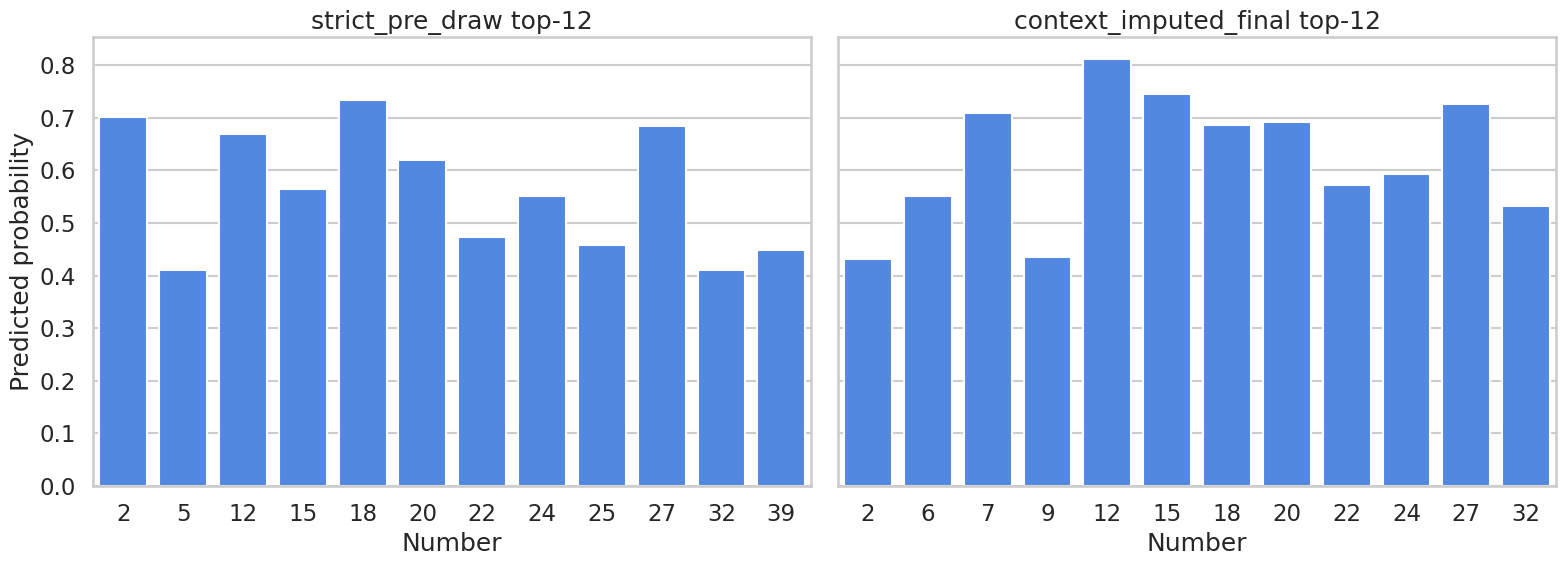

In [8]:
fig, axes = plt.subplots(1, len(recommendations), figsize=(8 * len(recommendations), 6), sharey=True)
if len(recommendations) == 1:
    axes = [axes]
for ax, rec in zip(axes, recommendations):
    top12 = rec.probability_frame.head(12).copy()
    sns.barplot(data=top12, x="number", y="predicted_probability", ax=ax, color="#3b82f6")
    ax.set_title(f"{rec.candidate_name} top-12")
    ax.set_xlabel("Number")
    ax.set_ylabel("Predicted probability")
plt.tight_layout()
plt.show()

In [9]:
figure_path = FIGURES_DIR / "fig_50_next_draw_top12_probabilities.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

summary_export, ranking_export = export_next_draw_outputs(recommendations)

figure_path, summary_export.head(), ranking_export.head()

(PosixPath('/workspace/reports/figures/fig_50_next_draw_top12_probabilities.png'),
           candidate_name        feature_set                 model  \
 0        strict_pre_draw  base_plus_pattern  soft_voting_ensemble   
 1  context_imputed_final   full_feature_set  soft_voting_ensemble   
 
   training_regime  next_round next_draw_date            ticket_top6  \
 0        last_500        1224     2026-05-16  2, 12, 15, 18, 20, 27   
 1        last_500        1224     2026-05-16  7, 12, 15, 18, 20, 27   
 
                                   top12_numbers      weighted_ticket_1  \
 0  18, 2, 27, 12, 20, 15, 24, 22, 25, 39, 32, 5  5, 18, 26, 29, 34, 43   
 1    12, 15, 27, 7, 20, 18, 24, 22, 6, 32, 9, 2  6, 18, 26, 27, 33, 41   
 
     diversified_ticket_1                                        assumptions  
 0  2, 12, 15, 18, 20, 27  next_round=1224; next_draw_date=2026-05-16; fe...  
 1  7, 12, 15, 18, 20, 27  next_round=1224; next_draw_date=2026-05-16; fe...  ,
     candidate_name  n